In [1]:
import numpy as np
import torch
from flonacomldft.gaussian_utils import MoG
import matplotlib.pyplot as plt

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Target model - Gaussian mixture

In [2]:
sep = 2.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-1 * torch.eye(2)]

target = MoG(means, covars, weights=[0.2, 0.8])
generator = MoG(means, covars, weights=[0.5, 0.5])

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/torch/functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


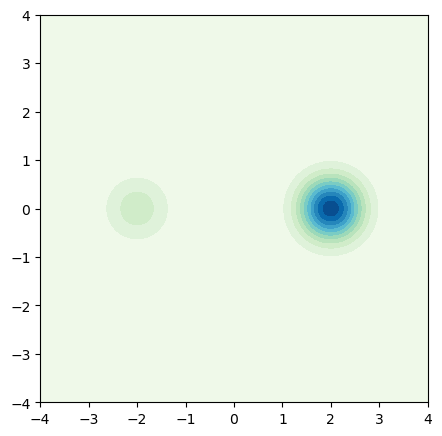

In [3]:
lims = {'x_min':-2 * sep, 'x_max':2 * sep, 'y_min':-2 * sep, 'y_max':2 * sep}
device = 'cpu'

def set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)


plt.figure(figsize=(5,7))
ax = plt.subplot(1,1,1)
set_plot(ax)

## Create dataset

In [4]:
n_samples = 5000

generator_samples = generator.sample(n_samples)
generator_us = target.U(generator_samples)
id_mode = (generator_samples[:, 0] >  0).int()

dataset = torch.cat([generator_samples.T, generator_us.reshape(1, -1), id_mode.reshape(1, -1)]).T

datasets = [dataset[dataset[:, -1] == i] for i in range(2)]

train = [datasets[i][:int(0.8 * len(datasets[i]))] for i in range(2)]
test = [datasets[i][int(0.8 * len(datasets[i])):] for i in range(2)]

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/torch/distributions/distribution.py:159: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


### Plot samples from dataset according to mode label

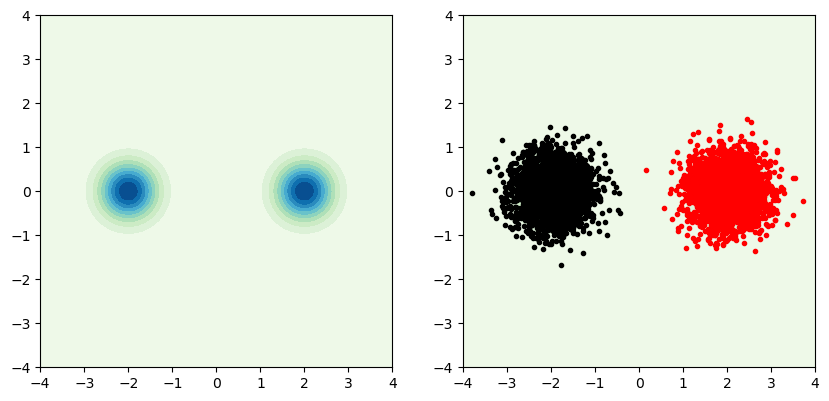

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
set_plot(axs[0], target_log_prob=generator.log_prob)
set_plot(axs[1], target_log_prob=generator.log_prob)
axs[1].scatter(dataset[dataset[:, -1]==0].T[0], dataset[dataset[:, -1]==0].T[1], marker='.', color='k', alpha=1)
axs[1].scatter(dataset[dataset[:, -1]==1].T[0], dataset[dataset[:, -1]==1].T[1], marker='.', color='r', alpha=1)

## Create flows

In [6]:
import copy
from flonacomldft.models.real_nvp import RealNVP_MLP
from flonacomldft.train_flow_from_data import train_flow

In [7]:
n_blocks = 4
hidden_dim = 64
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-3,
                    base_cov=None,
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

flows_dic = [train_flow(
    copy.deepcopy(model),
    train[i],
    test[i],
    dim=2,
    n_iter=75,
    lr=1e-3,
    use_scheduler=False,
    step_schedule=int(100000/10),
    save_splits=10,
    grad_clip=1e4,
    with_tqdm=False,
    )  for i in range(2)]

t=0.0e+00 	 loss: 4.04	Gd: 2e+00	lr: 1.00e-03
t=1.5e+01 	 loss: 3.91	Gd: 2e+00	lr: 1.00e-03
t=3.0e+01 	 loss: 3.57	Gd: 2e+00	lr: 1.00e-03
t=4.5e+01 	 loss: 2.91	Gd: 1e+00	lr: 1.00e-03
t=6.0e+01 	 loss: 2.32	Gd: 7e-01	lr: 1.00e-03
t=0.0e+00 	 loss: 4.06	Gd: 2e+00	lr: 1.00e-03
t=1.5e+01 	 loss: 3.92	Gd: 2e+00	lr: 1.00e-03
t=3.0e+01 	 loss: 3.57	Gd: 2e+00	lr: 1.00e-03
t=4.5e+01 	 loss: 2.89	Gd: 1e+00	lr: 1.00e-03
t=6.0e+01 	 loss: 2.30	Gd: 7e-01	lr: 1.00e-03


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


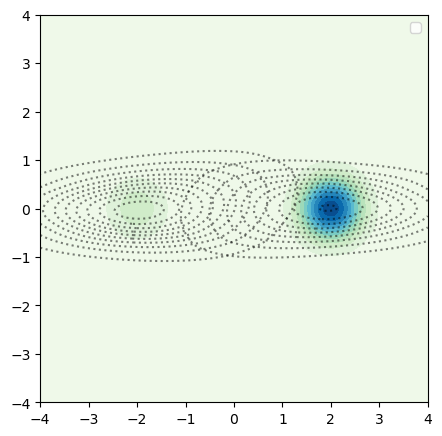

In [8]:
fig, ax = plt.subplots(1,1, figsize=(5,7))
flowlogprob = lambda x: -flows_dic[0]['model'].nll(x)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)
flowlogprob = lambda x: -flows_dic[1]['model'].nll(x)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)

plt.legend()

In [9]:
from ase.units import kB 
T = 300
beta = 1 / (kB * T)

## Energy setup

In [10]:
target_energy = lambda x: target.U(x) / beta
mlps_dic = [{'model': target_energy}, {'model': target_energy}]

In [11]:
from flonacomldft.full_adaptive_sampling import adaptive_sampling

In [12]:
flow_hyperparams = {'n_iter': 100,
    'lr': 1e-3,
    'use_scheduler': False,
    'step_schedule': 100,
    'save_splits': 10,
    'grad_clip': 1e4}


## Adaptive sampling no reweighting

In [13]:
n_runs = 10
n_chains = 25
n_steps = 50

init_samples = generator.sample(n_chains)
init_us = target.U(init_samples)
init_id_mode = (init_samples[:, 0] > 0).int()

init_mcmc = torch.cat([init_samples.T, init_us.reshape(1, -1), init_id_mode.reshape(1, -1)]).T

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/torch/distributions/distribution.py:159: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


In [14]:
## putting all data set in one

full_train = torch.cat(train)
full_test = torch.cat(test)

In [15]:
_ = adaptive_sampling(full_train, 
                        full_test,
                         init_mcmc, 
                         dim=2,
                         dict_flows_init=flows_dic,
                         dict_mlps_init=mlps_dic,
                         mixture=True,
                         flow_hyperparams=[flow_hyperparams, flow_hyperparams],
                         n_runs=n_runs,
                         n_chains=n_chains,
                         n_steps=n_steps,
                        )

step: 0 	 acc: 1.00
step: 5 	 acc: 0.16
step: 10 	 acc: 0.24
step: 15 	 acc: 0.32
step: 20 	 acc: 0.32
step: 25 	 acc: 0.20
step: 30 	 acc: 0.16
step: 35 	 acc: 0.40
step: 40 	 acc: 0.40
step: 45 	 acc: 0.20
t=0.0e+00 	 loss: 2.05	Gd: 5e-01	lr: 1.00e-03
t=1.0e+01 	 loss: 1.92	Gd: 5e-01	lr: 1.00e-03
t=2.0e+01 	 loss: 1.85	Gd: 4e-01	lr: 1.00e-03
t=3.0e+01 	 loss: 1.80	Gd: 3e-01	lr: 1.00e-03
t=4.0e+01 	 loss: 1.77	Gd: 3e-01	lr: 1.00e-03
t=5.0e+01 	 loss: 1.75	Gd: 3e-01	lr: 1.00e-03
t=6.0e+01 	 loss: 1.74	Gd: 3e-01	lr: 1.00e-03
t=7.0e+01 	 loss: 1.72	Gd: 3e-01	lr: 1.00e-03
t=8.0e+01 	 loss: 1.71	Gd: 3e-01	lr: 1.00e-03
t=9.0e+01 	 loss: 1.69	Gd: 2e-01	lr: 1.00e-03
t=0.0e+00 	 loss: 2.03	Gd: 6e-01	lr: 1.00e-03
t=1.0e+01 	 loss: 1.89	Gd: 6e-01	lr: 1.00e-03
t=2.0e+01 	 loss: 1.80	Gd: 5e-01	lr: 1.00e-03
t=3.0e+01 	 loss: 1.73	Gd: 4e-01	lr: 1.00e-03
t=4.0e+01 	 loss: 1.69	Gd: 4e-01	lr: 1.00e-03
t=5.0e+01 	 loss: 1.65	Gd: 4e-01	lr: 1.00e-03
t=6.0e+01 	 loss: 1.63	Gd: 4e-01	lr: 1.00e-03
t=7.0e+01 

In [16]:
from flonacomldft.models.mixture import Mixture

In [17]:
get_model = lambda dics: [dic['model'] for dic in dics]

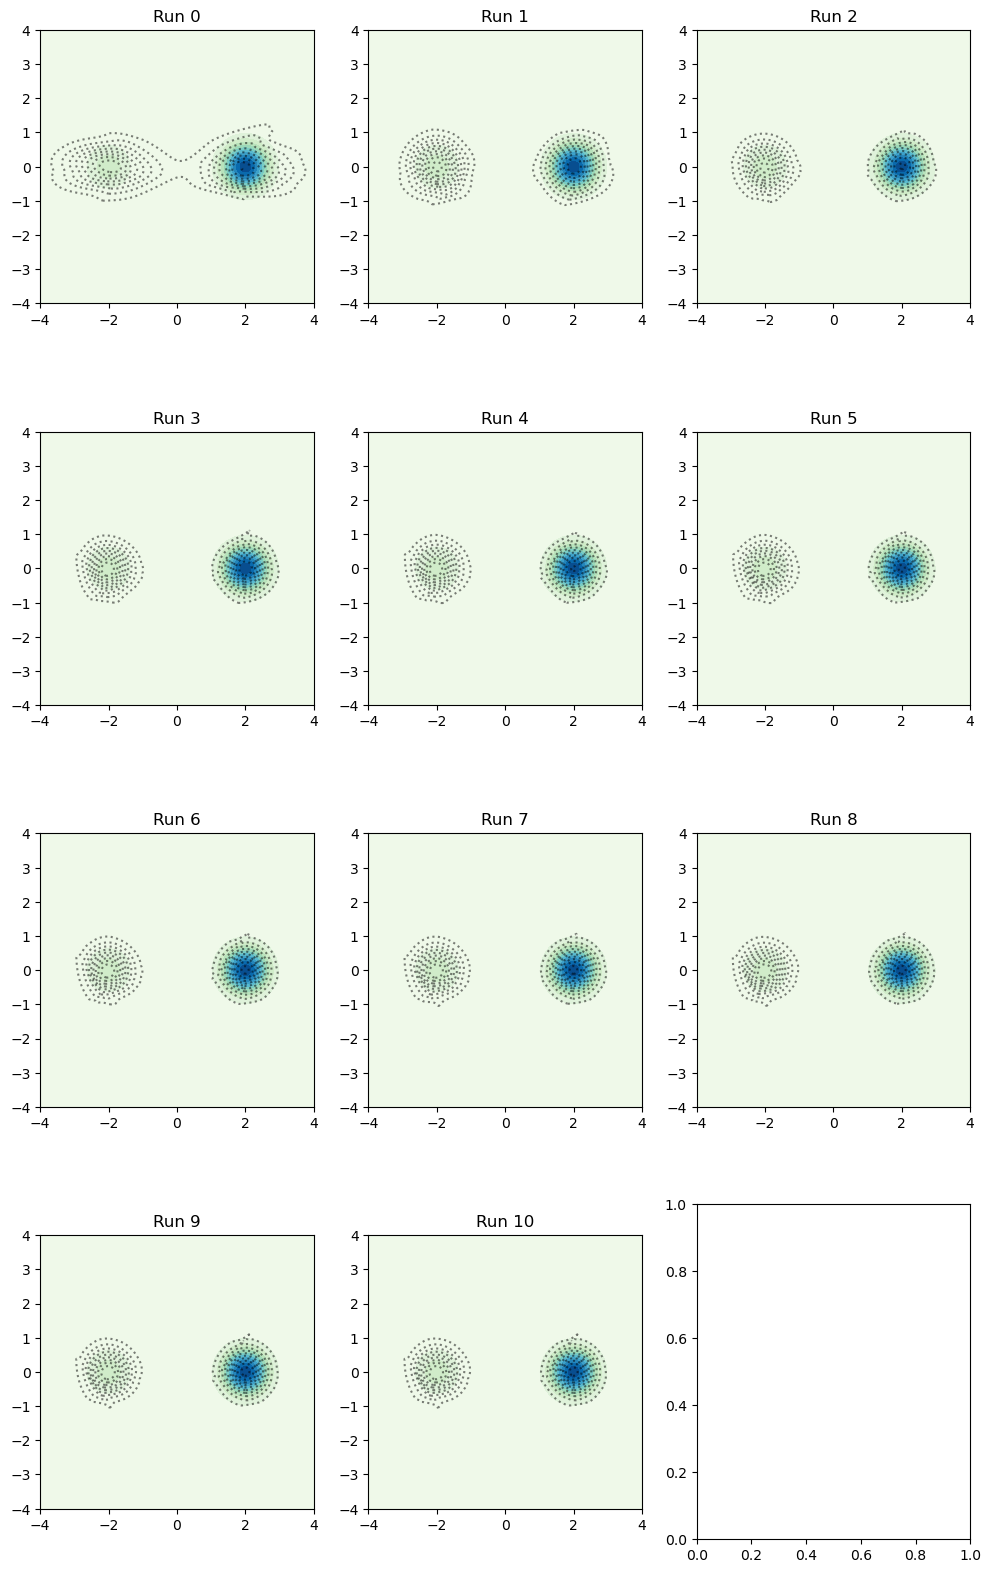

In [18]:
fig, axs = plt.subplots(4, 3, figsize=(12,20))

axs = axs.ravel()
for ax, i in zip(axs, list(range(len(_['dict_flows_training'])))):
    weights = torch.tensor([0.5, 0.5])
    model = Mixture(get_model(_['dict_flows_training'][i]), weights)
    flowlogprob = lambda x: -model.nll(x)
    set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)
    ax.set_title('Run {}'.format(i))


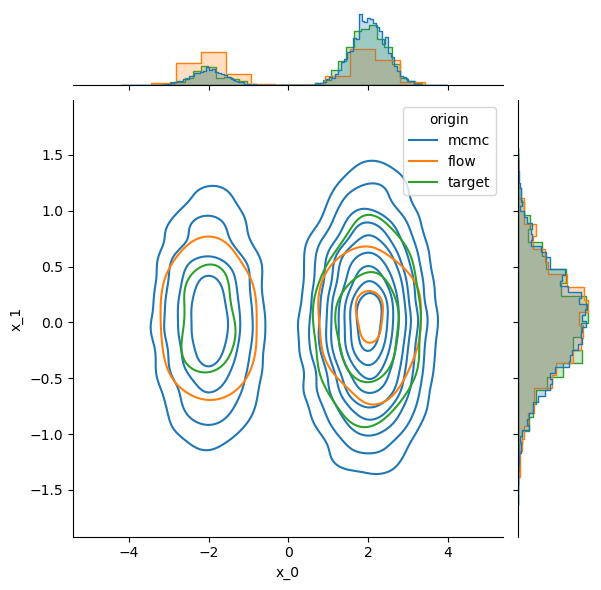

In [19]:
xs = torch.stack(_['xs']).squeeze().reshape(-1, 2)
flow_samples = model.sample(1000)
target_samples = target.sample(1000)     

import seaborn as sns
import pandas as pd

datas = [
            xs.view(-1,2).detach().numpy(), 
            flow_samples.detach().numpy(),
            target_samples.detach().numpy()
]
labels = ['mcmc', 
          'flow', 
          'target'
]

frames = []
for d, l in zip(datas, labels):
    df = pd.DataFrame(
        {"x_{:d}".format(0): d[:,0], "x_{:d}".format(1): d[:, 1]}
    )
    df["origin"] = l
    frames.append(df)

dfs = pd.concat(frames, ignore_index=True)
g = sns.JointGrid(
    data=dfs, x="x_{:d}".format(0), y="x_{:d}".format(1), hue="origin"
)
g.plot_joint(sns.kdeplot)
g.plot_marginals(sns.histplot, element="step", fill=True, stat='density', common_bins=False, common_norm=False)

## Acceptance while training

In [20]:
from flonacomldft.utils.diagnostics import avg_windows
from flonacomldft.utils.plots import set_plot_iteration

In [21]:
accs = torch.stack(_['accs'])
accs_flatten = accs.reshape(-1, n_chains)

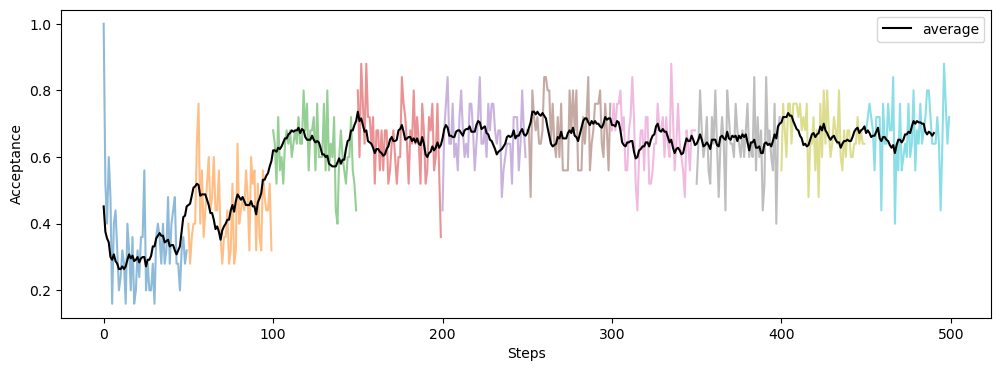

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(12,4) )
i=0
for acc in accs:
    set_plot_iteration(acc.mean(dim=1), avg=False, window_size=10, axis=1, ax=ax, init=i)
    if i > 0:
        i += acc.shape[0]
    else:
        i += acc.shape[0]

window_size = 10
axis = 1

x_avg = np.arange(len(avg_windows(accs_flatten.mean(dim=1), window_size, axis)))
y_avg = avg_windows(accs_flatten.mean(dim=1), window_size, axis)
ax.plot(x_avg, y_avg, color="k", label='average')

ax.set_xlabel('Steps')
ax.set_ylabel('Acceptance')
ax.legend()

## Plotting the losses

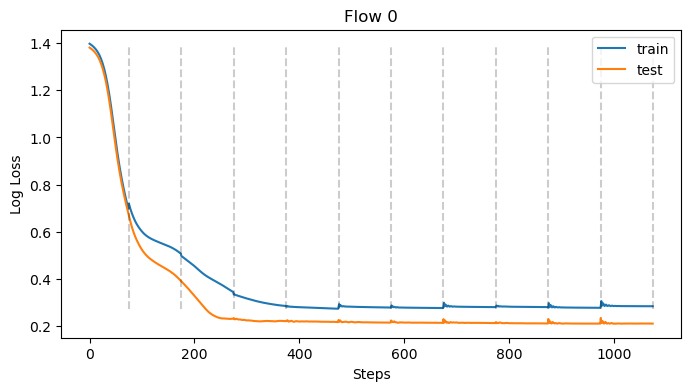

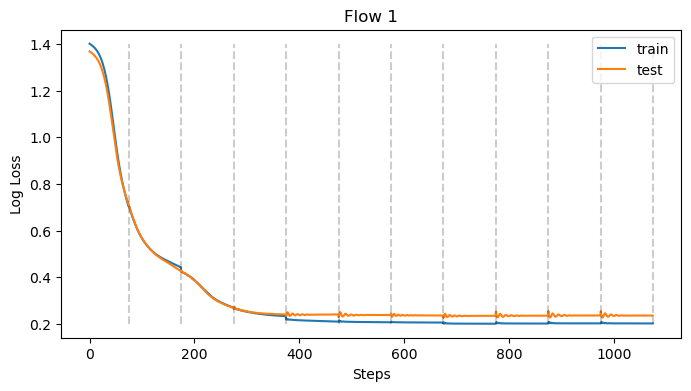

In [23]:
dict_flows_training = _['dict_flows_training']

for j in range(2):

    losses_train = torch.cat([torch.tensor(dict_flows_training[i][j]['losses'][0]) for i in range(len(dict_flows_training))])
    losses_test = torch.cat([torch.tensor(dict_flows_training[i][j]['losses'][1]) for i in range(len(dict_flows_training))])

    y_lines = np.cumsum([len(dict_flows_training[i][j]['losses'][0]) for i in range(len(dict_flows_training))])

    fig, ax = plt.subplots(1, 1, figsize=(8,4) )
    set_plot_iteration(torch.log(losses_train), avg=False, window_size=10, axis=0, alpha=1, ax=ax, label='train')
    set_plot_iteration(torch.log(losses_test), avg=False, window_size=10, axis=0,alpha=1, ax=ax, label='test')

    ax.vlines(y_lines, ymin=torch.log(losses_train.min()), ymax=torch.log(losses_train.max()), color='k', alpha=0.2, linestyle='--')

    ax.set_xlabel('Steps')
    ax.set_ylabel('Log Loss')
    ax.set_label(['train', 'test'])
    ax.legend()

    ax.set_title('Flow {}'.format(j))    

## Adaptive sampling reweighting

In [24]:
_weighted = adaptive_sampling(full_train, 
                        full_test,
                         init_mcmc, 
                         dim=2,
                         dict_flows_init=flows_dic,
                         dict_mlps_init=mlps_dic,
                         mixture=True,
                         flow_hyperparams=[flow_hyperparams, flow_hyperparams],
                         n_runs=n_runs,
                         n_chains=n_chains,
                         n_steps=n_steps,
                         reweighting=True,
                        )

step: 0 	 acc: 1.00
step: 5 	 acc: 0.40
step: 10 	 acc: 0.32
step: 15 	 acc: 0.24
step: 20 	 acc: 0.32
step: 25 	 acc: 0.40
step: 30 	 acc: 0.24
step: 35 	 acc: 0.24
step: 40 	 acc: 0.28
step: 45 	 acc: 0.24
t=0.0e+00 	 loss: 2.07	Gd: 5e-01	lr: 1.00e-03
t=1.0e+01 	 loss: 1.95	Gd: 4e-01	lr: 1.00e-03
t=2.0e+01 	 loss: 1.89	Gd: 4e-01	lr: 1.00e-03
t=3.0e+01 	 loss: 1.85	Gd: 3e-01	lr: 1.00e-03
t=4.0e+01 	 loss: 1.83	Gd: 3e-01	lr: 1.00e-03
t=5.0e+01 	 loss: 1.81	Gd: 2e-01	lr: 1.00e-03
t=6.0e+01 	 loss: 1.79	Gd: 2e-01	lr: 1.00e-03
t=7.0e+01 	 loss: 1.78	Gd: 2e-01	lr: 1.00e-03
t=8.0e+01 	 loss: 1.75	Gd: 2e-01	lr: 1.00e-03
t=9.0e+01 	 loss: 1.72	Gd: 2e-01	lr: 1.00e-03
t=0.0e+00 	 loss: 2.02	Gd: 5e-01	lr: 1.00e-03
t=1.0e+01 	 loss: 1.89	Gd: 5e-01	lr: 1.00e-03
t=2.0e+01 	 loss: 1.81	Gd: 4e-01	lr: 1.00e-03
t=3.0e+01 	 loss: 1.75	Gd: 4e-01	lr: 1.00e-03
t=4.0e+01 	 loss: 1.70	Gd: 4e-01	lr: 1.00e-03
t=5.0e+01 	 loss: 1.67	Gd: 3e-01	lr: 1.00e-03
t=6.0e+01 	 loss: 1.65	Gd: 3e-01	lr: 1.00e-03
t=7.0e+01 

In [25]:
from flonacomldft.full_adaptive_sampling import get_weights


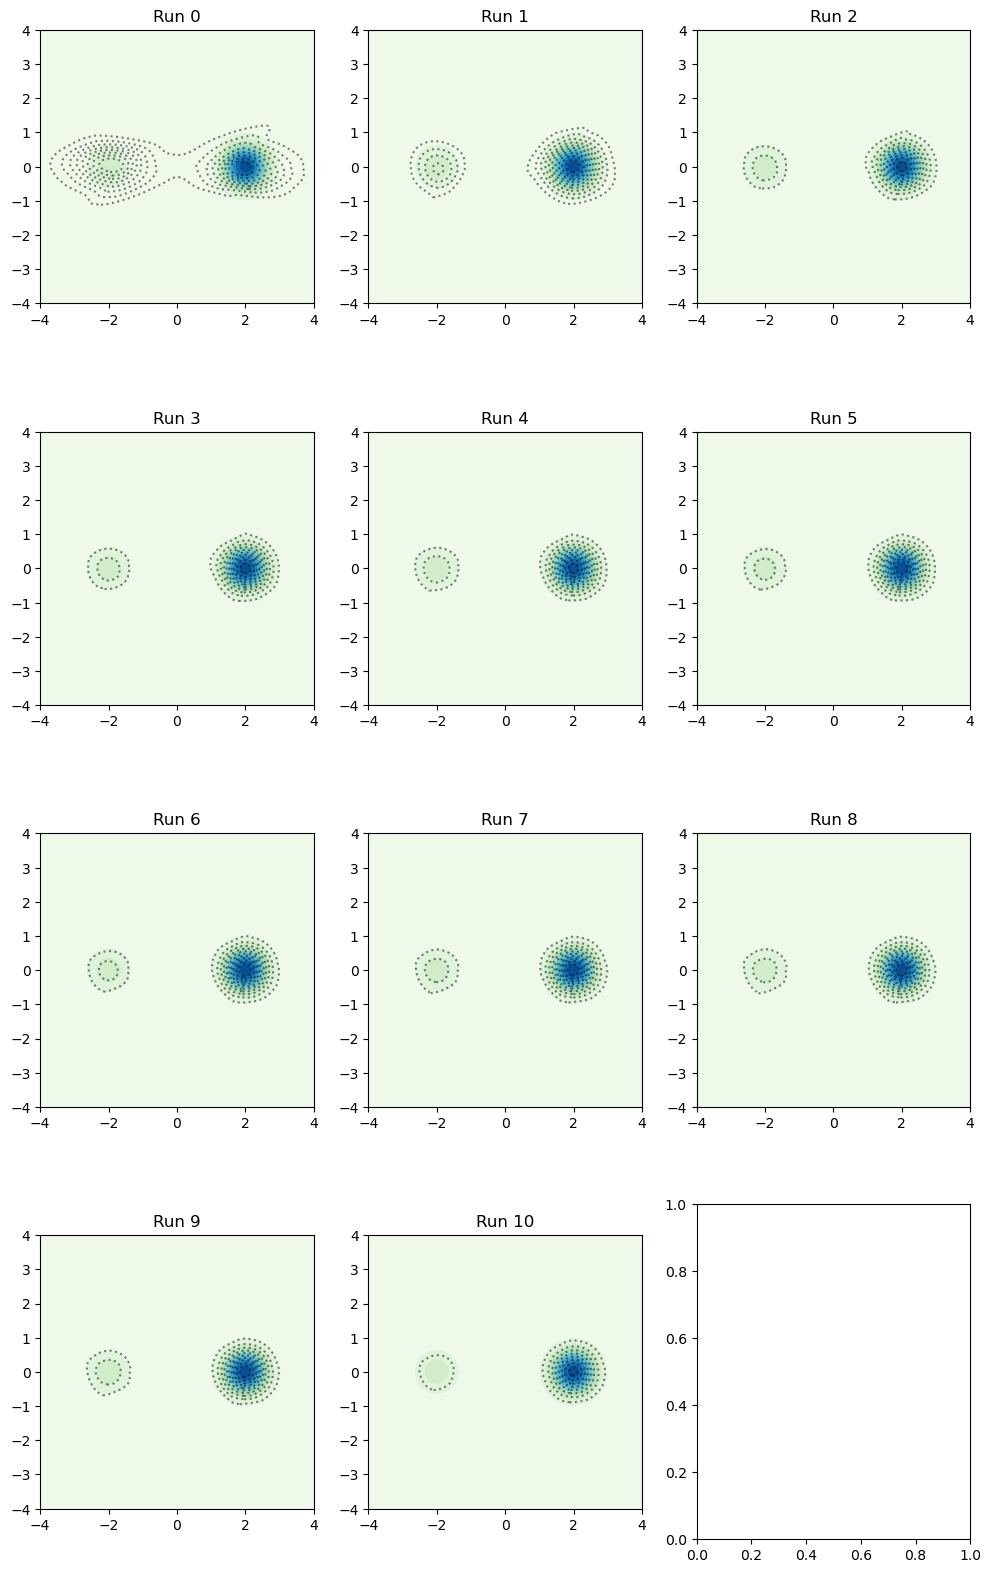

In [26]:
fig, axs = plt.subplots(4, 3, figsize=(12,20))

axs = axs.ravel()
for ax, i in zip(axs, list(range(len(_weighted['dict_flows_training'])))):
    if i == 0:
        weights = torch.tensor([0.5, 0.5])
    else:
        weights = get_weights(_weighted['isomers'][i-1])
    model = Mixture(get_model(_weighted['dict_flows_training'][i]), weights)
    flowlogprob = lambda x: -model.nll(x)
    set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)
    ax.set_title('Run {}'.format(i))

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/torch/distributions/distribution.py:159: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


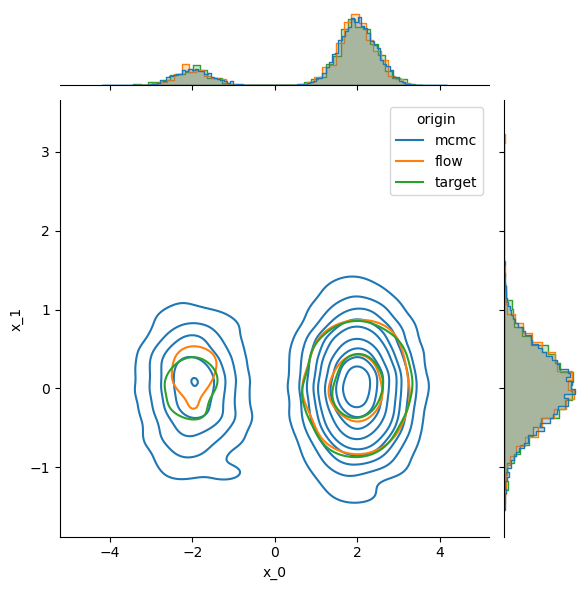

In [27]:
xs = torch.stack(_weighted['xs']).squeeze().reshape(-1, 2)
flow_samples = model.sample(1000)
target_samples = target.sample(1000)     

import seaborn as sns
import pandas as pd

datas = [
            xs.view(-1,2).detach().numpy(), 
            flow_samples.detach().numpy(),
            target_samples.detach().numpy()
]
labels = ['mcmc', 
          'flow', 
          'target'
]

frames = []
for d, l in zip(datas, labels):
    df = pd.DataFrame(
        {"x_{:d}".format(0): d[:,0], "x_{:d}".format(1): d[:, 1]}
    )
    df["origin"] = l
    frames.append(df)

dfs = pd.concat(frames, ignore_index=True)
g = sns.JointGrid(
    data=dfs, x="x_{:d}".format(0), y="x_{:d}".format(1), hue="origin"
)
g.plot_joint(sns.kdeplot)
g.plot_marginals(sns.histplot, element="step", fill=True, stat='density', common_bins=False, common_norm=False)

## Acceptance while training

In [28]:
accs = torch.stack(_weighted['accs'])
accs_flatten = accs.reshape(-1, n_chains)

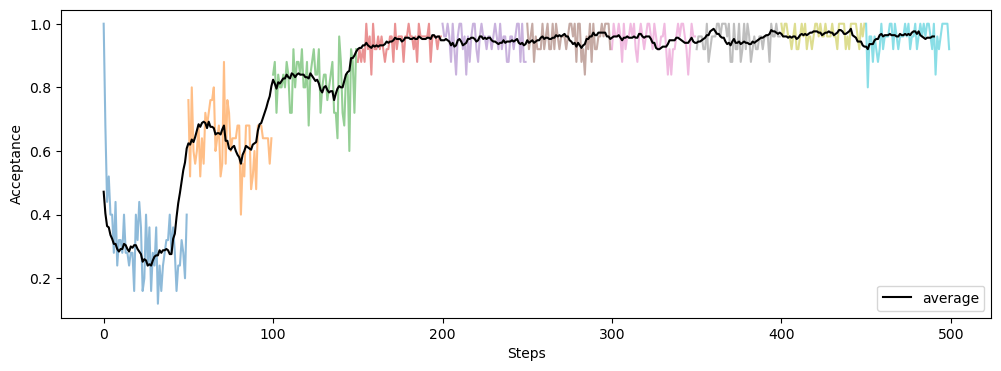

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(12,4) )
i=0
for acc in accs:
    set_plot_iteration(acc.mean(dim=1), avg=False, window_size=10, axis=1, ax=ax, init=i)
    if i > 0:
        i += acc.shape[0]
    else:
        i += acc.shape[0]

window_size = 10
axis = 1

x_avg = np.arange(len(avg_windows(accs_flatten.mean(dim=1), window_size, axis)))
y_avg = avg_windows(accs_flatten.mean(dim=1), window_size, axis)
ax.plot(x_avg, y_avg, color="k", label='average')

ax.set_xlabel('Steps')
ax.set_ylabel('Acceptance')
ax.legend()

## Plotting the losses

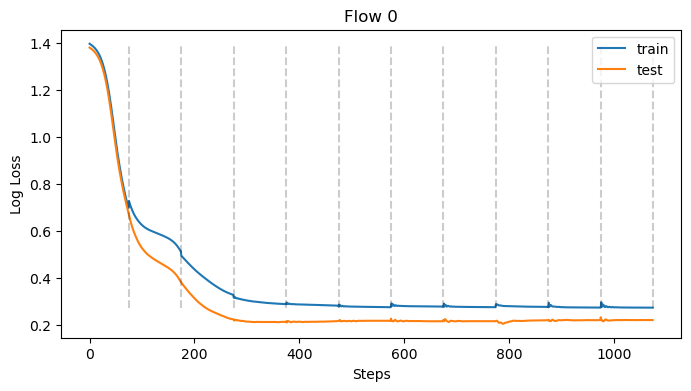

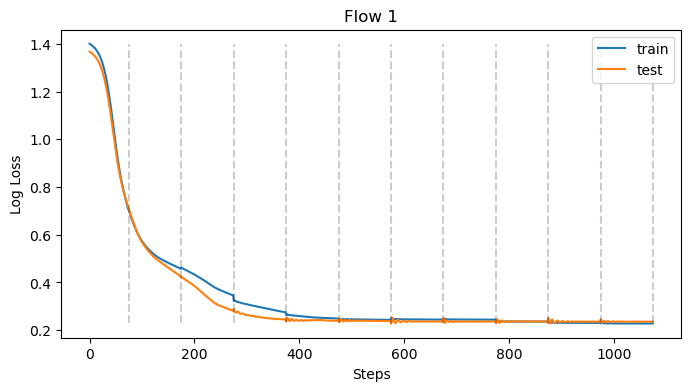

In [30]:
dict_flows_training = _weighted['dict_flows_training']

for j in range(2):

    losses_train = torch.cat([torch.tensor(dict_flows_training[i][j]['losses'][0]) for i in range(len(dict_flows_training))])
    losses_test = torch.cat([torch.tensor(dict_flows_training[i][j]['losses'][1]) for i in range(len(dict_flows_training))])

    y_lines = np.cumsum([len(dict_flows_training[i][j]['losses'][0]) for i in range(len(dict_flows_training))])

    fig, ax = plt.subplots(1, 1, figsize=(8,4) )
    set_plot_iteration(torch.log(losses_train), avg=False, window_size=10, axis=0, alpha=1, ax=ax, label='train')
    set_plot_iteration(torch.log(losses_test), avg=False, window_size=10, axis=0,alpha=1, ax=ax, label='test')

    ax.vlines(y_lines, ymin=torch.log(losses_train.min()), ymax=torch.log(losses_train.max()), color='k', alpha=0.2, linestyle='--')

    ax.set_xlabel('Steps')
    ax.set_ylabel('Log Loss')
    ax.set_label(['train', 'test'])
    ax.legend()

    ax.set_title('Flow {}'.format(j))    